# Recurrent Smoothing Tau Grid Search

Grid search over `recurrent_smoothing_tau` ∈ {50, 100, 200, 500} ms for OU-rates training.

The smoothing parameter controls the Gaussian kernel sigma used to smooth recurrent teacher spikes before Bernoulli-resampling them as model inputs. Larger tau → smoother rate estimates → less temporal information in the recurrent inputs.

In [ ]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import zarr

from utils.reproducibility import load_experiment_config
from visualization import (
    use_project_style,
    EXCITATORY_COLOR,
    INHIBITORY_COLOR,
    TEACHER_COLOR,
    STUDENT_COLOR,
    plot_firing_rate_scatter,
    plot_r2_comparison_bar,
    plot_r2_vs_parameter,
    plot_spike_trains,
    plot_sf_bar_chart,
)
from visualization.scaling_factors import SF_PATHWAYS, plot_sf_trajectories
from analysis import (
    r_squared,
    fluctuation_r_squared,
    firing_rates_from_spikes,
    interleave_spike_trains,
    make_grid_colormap,
)
from analysis.inference import run_feedforward_inference
from dataloaders.supervised._smoothing import smooth_spike_trains

use_project_style()

In [ ]:
ou_rates_config = load_experiment_config("experiment.toml")
GRID_DIR = ou_rates_config["output_dir"]
PARAMS_FILE = ou_rates_config["parameters_file"]
MAX_RATE = 40
TICKS = np.arange(0, MAX_RATE + 10, 10)
TAU_MS = 50.0
N_NEURONS_RASTER = 10
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

In [3]:
# Scaling factor matrix index map: SF_PATHWAYS order → (row, col) in the (3,2) matrix
_SF_INDEX_MAP = [
    (0, 0),  # mitral_to_excitatory  (FF → Exc)
    (0, 1),  # mitral_to_inhibitory  (FF → Inh)
    (1, 0),  # excitatory_to_excitatory
    (1, 1),  # excitatory_to_inhibitory
    (2, 0),  # inhibitory_to_excitatory
    (2, 1),  # inhibitory_to_inhibitory
]


def run_exact_inference(tau, run_info, *, sf_keys):
    """Run inference with exact recurrent spikes and regenerated FF spikes."""
    strat_dir = run_info["dir"]
    cache_path = strat_dir / "final_state" / "plot_data_exact_recurrent.npz"

    # Compute scaling factors from CSV * target
    df_metrics = run_info["df"]
    grad_rows = df_metrics[df_metrics["epoch"] >= 0]
    final_row = grad_rows.iloc[-1]

    targets = np.load(strat_dir / "targets" / "target_scaling_factors.npz")
    target_sf = targets["feedforward_scaling_factors"]
    scaling_factors_FF = np.zeros_like(target_sf)
    for i, k in enumerate(sf_keys):
        r, c = _SF_INDEX_MAP[i]
        scaling_factors_FF[r, c] = (
            float(final_row[f"scaling_factors/{k}_value"]) * target_sf[r, c]
        )

    # Regenerate FF spikes from OU weights (fresh Poisson sample)
    zarr_root = zarr.open_group(strat_dir / "inputs" / "spike_data.zarr", mode="r")
    dt = float(zarr_root.attrs["dt"])
    ou_weights = np.array(zarr_root["weights"][0])  # (time, n_patterns)
    patterns = np.array(zarr_root["odourant_patterns"])  # (n_patterns, n_ff)
    rates_hz = ou_weights @ patterns  # (time, n_ff)
    spike_prob = rates_hz * (dt / 1000.0)
    rng = np.random.default_rng(123)
    ff_input = (rng.random(spike_prob.shape) < spike_prob).astype(np.float32)

    return run_feedforward_inference(
        params_file=PARAMS_FILE,
        run_dir=strat_dir,
        scaling_factors_FF=scaling_factors_FF,
        ff_input=ff_input,
        cache_path=cache_path,
        device=DEVICE,
        desc=f"tau={tau}",
    )

In [4]:
# Discover runs — directories named tau-{value}
run_dirs = sorted(
    [d for d in GRID_DIR.iterdir() if d.is_dir() and d.name.startswith("tau-")],
    key=lambda d: float(re.search(r"tau-(\d+)", d.name).group(1)),
)

runs = {}
for d in run_dirs:
    tau = float(re.search(r"tau-(\d+)", d.name).group(1))
    csv_path = d / "training_metrics.csv"
    if csv_path.exists():
        runs[tau] = {"dir": d, "df": pd.read_csv(csv_path)}
    else:
        print(f"WARNING: no training_metrics.csv in {d.name}")

taus = sorted(runs.keys())
print(f"Found {len(runs)} runs: tau = {taus}")

sf_keys = [key for key, _ in SF_PATHWAYS]
sf_labels = [label for _, label in SF_PATHWAYS]

Found 6 runs: tau = [50.0, 100.0, 200.0, 500.0, 1000.0, 2000.0]


## Training Curves

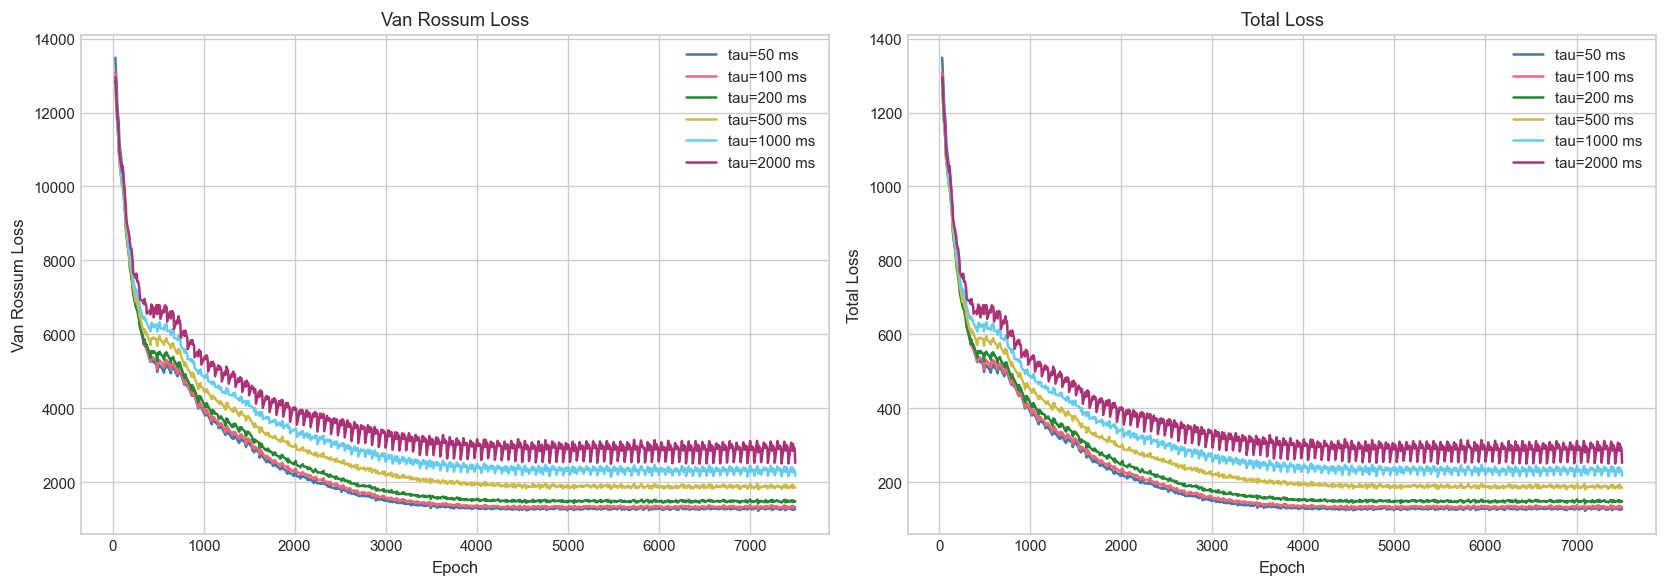

In [5]:
_, tau_colors = make_grid_colormap(taus)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Van Rossum loss
ax = axes[0]
for tau in taus:
    df = runs[tau]["df"]
    grad = df[df["epoch"] >= 0]
    ax.plot(
        grad["epoch"],
        grad["van_rossum_loss"],
        color=tau_colors[tau],
        label=f"tau={tau:.0f} ms",
    )
ax.set_xlabel("Epoch")
ax.set_ylabel("Van Rossum Loss")
ax.set_title("Van Rossum Loss")
ax.legend()

# Right: total loss
ax = axes[1]
for tau in taus:
    df = runs[tau]["df"]
    grad = df[df["epoch"] >= 0]
    ax.plot(
        grad["epoch"],
        grad["total_loss"],
        color=tau_colors[tau],
        label=f"tau={tau:.0f} ms",
    )
ax.set_xlabel("Epoch")
ax.set_ylabel("Total Loss")
ax.set_title("Total Loss")
ax.legend()

plt.tight_layout()
plt.show()

## Scaling Factor Recovery

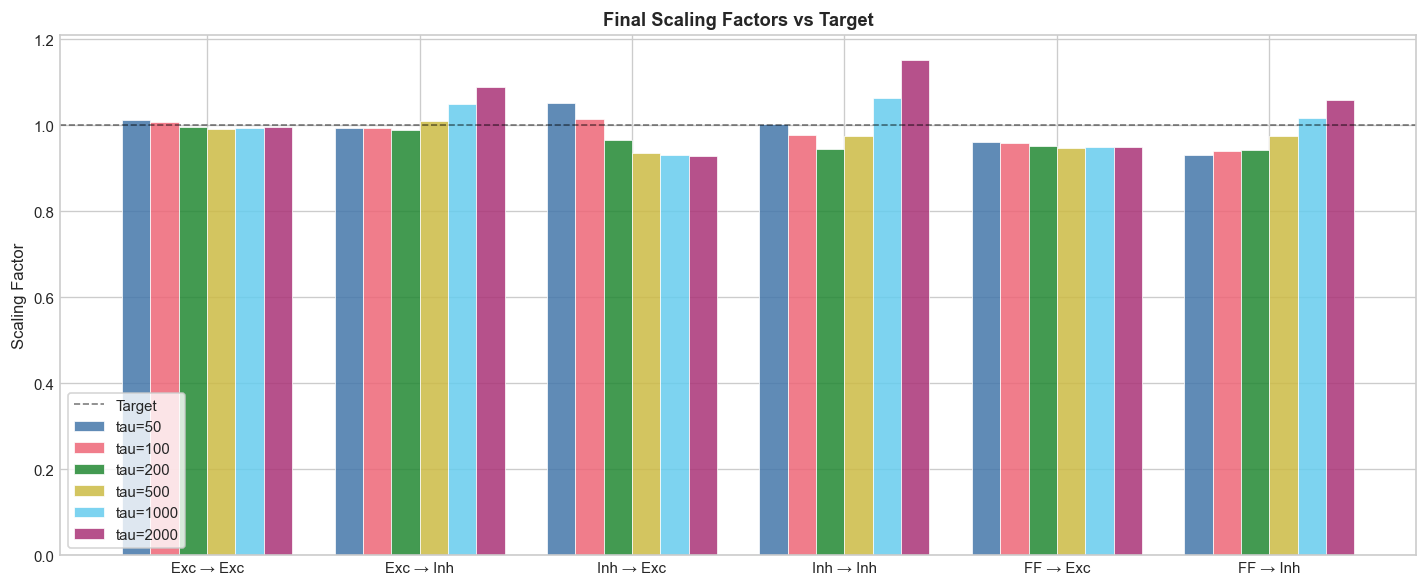

In [6]:
sf_data_tau = {}
for tau in taus:
    df = runs[tau]["df"]
    final = df[df["epoch"] >= 0].iloc[-1]
    sf_data_tau[f"tau={tau:.0f}"] = {
        key: float(final[f"scaling_factors/{key}_value"]) for key, _ in SF_PATHWAYS
    }

plot_sf_bar_chart(
    sf_data_tau,
    condition_labels=[f"tau={tau:.0f}" for tau in taus],
    condition_colors=[tau_colors[tau] for tau in taus],
    figsize=(12, 5),
    title="Final Scaling Factors vs Target",
)
plt.show()

## Scaling Factor Trajectories

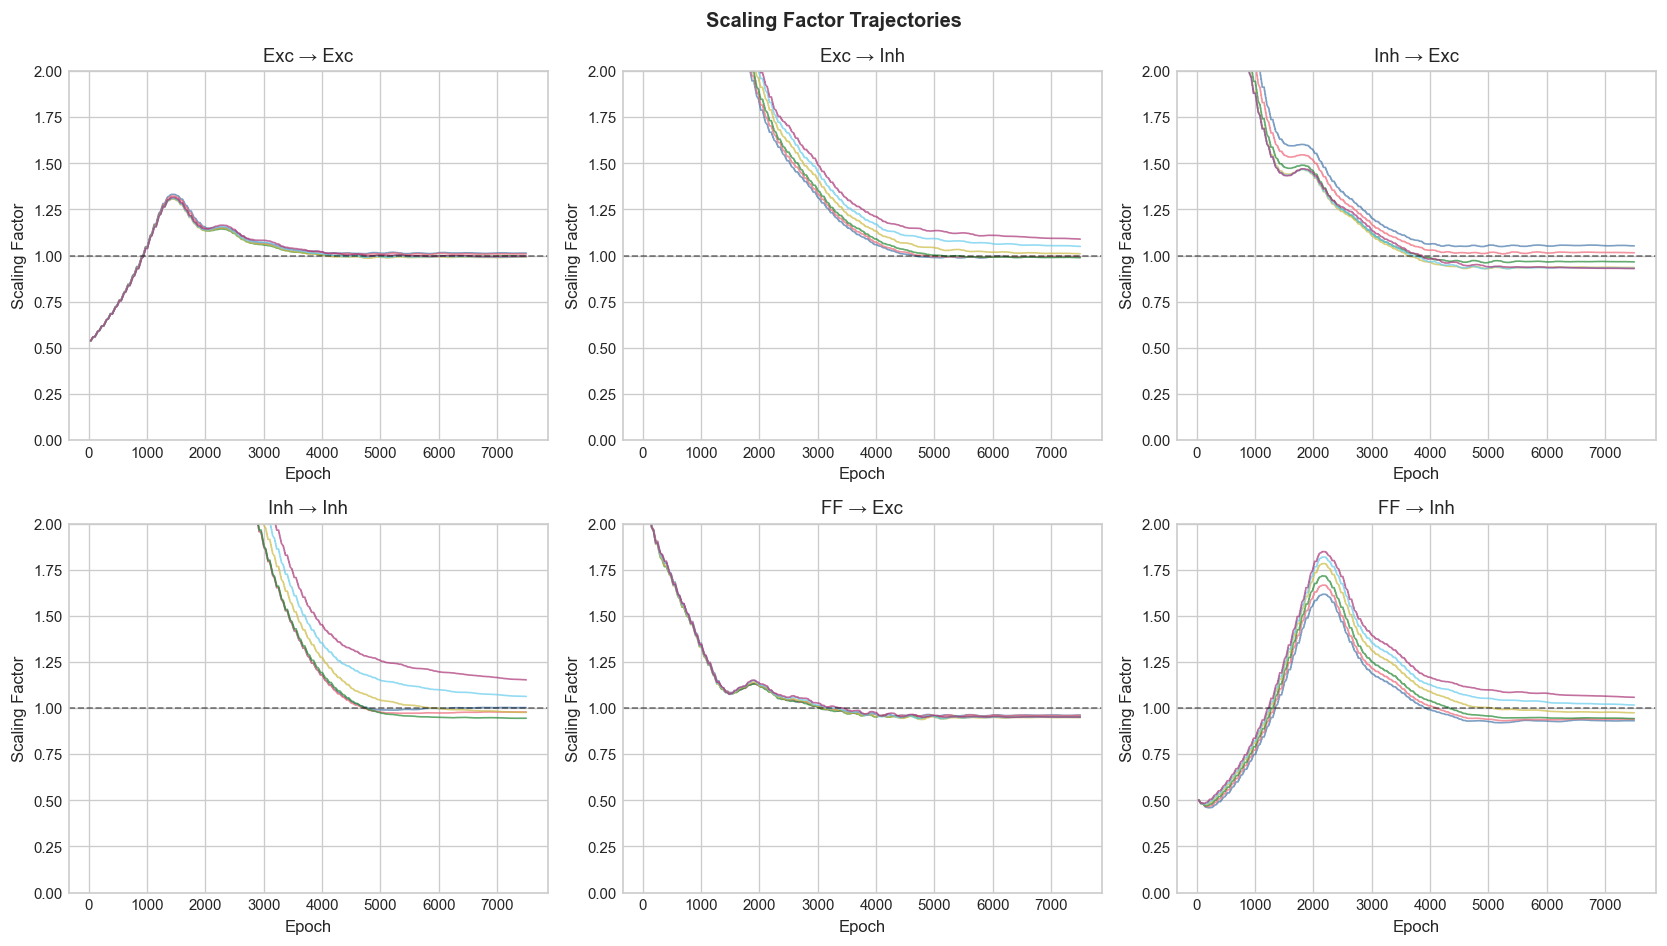

In [7]:
# Filter to gradient phase only (epoch >= 0)
runs_df_dict = {tau: runs[tau]["df"][runs[tau]["df"]["epoch"] >= 0] for tau in taus}

plot_sf_trajectories(
    runs_df_dict,
    colors=tau_colors,
    label_fn=lambda tau: f"tau={tau:.0f}",
    suptitle="Scaling Factor Trajectories",
)
plt.show()

## Firing Rates

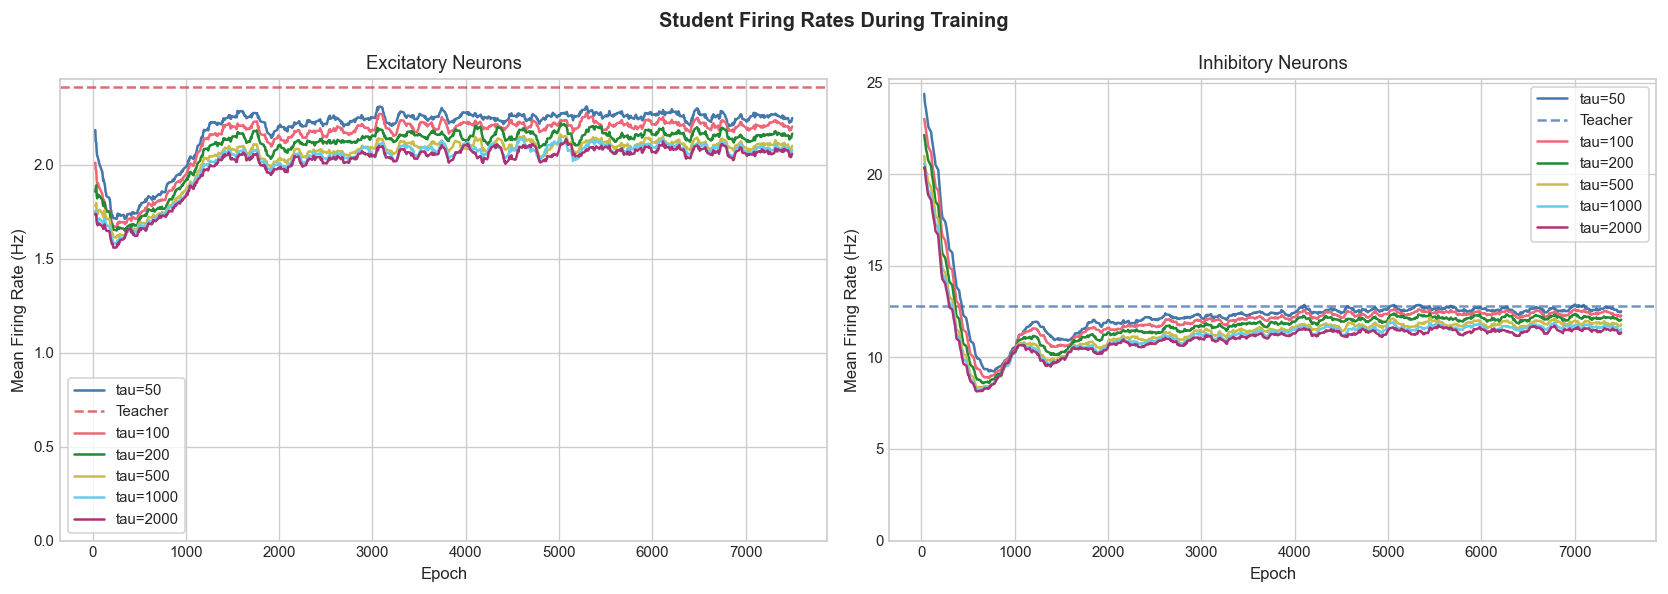

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ct_idx, (ct_label, color) in enumerate(
    [
        ("excitatory", EXCITATORY_COLOR),
        ("inhibitory", INHIBITORY_COLOR),
    ]
):
    ax = axes[ct_idx]
    for tau in taus:
        df = runs[tau]["df"]
        grad = df[df["epoch"] >= 0]
        col = f"firing_rate/student_{ct_label}_mean"
        if col in grad.columns:
            ax.plot(
                grad["epoch"], grad[col], color=tau_colors[tau], label=f"tau={tau:.0f}"
            )

        teacher_col = f"firing_rate/teacher_{ct_label}_mean"
        if teacher_col in grad.columns and tau == taus[0]:
            ax.axhline(
                grad[teacher_col].iloc[-1],
                color=color,
                linewidth=1.5,
                linestyle="--",
                alpha=0.7,
                label="Teacher",
            )

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Mean Firing Rate (Hz)")
    ax.set_title(f"{ct_label.capitalize()} Neurons")
    ax.set_ylim(0, None)
    ax.legend(fontsize=9, frameon=True)

fig.suptitle("Student Firing Rates During Training", fontweight="bold")
plt.tight_layout()
plt.show()

## Exact Recurrent Spikes Inference

Run each tau model with **exact** (unsmoothed) recurrent spikes and OU-rate-generated
feedforward inputs.  During training the recurrent input was smoothed and Bernoulli-resampled;
here we feed the raw teacher spikes directly to see how well the recovered scaling factors
generalise to the true spike trains.

Only the first batch element is used.

In [9]:
exact_data = {}
for tau in taus:
    exact_data[tau] = run_exact_inference(tau, runs[tau], sf_keys=sf_keys)

print("Done.")

Done.


## Smoothed vs Exact Recurrent Spikes

Compare student firing rates when driven by **exact** (raw) vs **smoothed + Bernoulli-resampled** teacher recurrent spikes, using the same final scaling factors for each tau.
This isolates the effect of the recurrent input regime on population firing rates.

In [11]:
def run_smoothed_inference(tau, run_info, *, sf_keys):
    """Run inference with smoothed+resampled recurrent spikes and OU-rate FF spikes."""
    strat_dir = run_info["dir"]
    cache_path = strat_dir / "final_state" / "plot_data_smoothed_recurrent.npz"

    # Same scaling factors as exact inference
    df_metrics = run_info["df"]
    grad_rows = df_metrics[df_metrics["epoch"] >= 0]
    final_row = grad_rows.iloc[-1]

    targets = np.load(strat_dir / "targets" / "target_scaling_factors.npz")
    target_sf = targets["feedforward_scaling_factors"]
    scaling_factors_FF = np.zeros_like(target_sf)
    for i, k in enumerate(sf_keys):
        r, c = _SF_INDEX_MAP[i]
        scaling_factors_FF[r, c] = (
            float(final_row[f"scaling_factors/{k}_value"]) * target_sf[r, c]
        )

    # Regenerate FF spikes from OU weights (same seed as exact)
    zarr_root = zarr.open_group(strat_dir / "inputs" / "spike_data.zarr", mode="r")
    dt = float(zarr_root.attrs["dt"])
    ou_weights = np.array(zarr_root["weights"][0])
    patterns = np.array(zarr_root["odourant_patterns"])
    rates_hz = ou_weights @ patterns
    spike_prob = rates_hz * (dt / 1000.0)
    rng = np.random.default_rng(123)
    ff_input = (rng.random(spike_prob.shape) < spike_prob).astype(np.float32)

    # Smooth teacher recurrent spikes and Bernoulli-resample
    teacher_out = np.array(zarr_root["output_spikes"][0])  # (time, neurons)
    teacher_torch = torch.from_numpy(teacher_out.astype(np.float32)).unsqueeze(0)
    smoothed_rates = smooth_spike_trains(teacher_torch, dt, tau).squeeze(0).numpy()
    rng_rec = np.random.default_rng(456)
    rec_input = (rng_rec.random(smoothed_rates.shape) < smoothed_rates).astype(
        np.float32
    )

    return run_feedforward_inference(
        params_file=PARAMS_FILE,
        run_dir=strat_dir,
        scaling_factors_FF=scaling_factors_FF,
        ff_input=ff_input,
        rec_input=rec_input,
        cache_path=cache_path,
        device=DEVICE,
        desc=f"tau={tau} smoothed",
    )

In [12]:
smoothed_data = {}
for tau in taus:
    smoothed_data[tau] = run_smoothed_inference(tau, runs[tau], sf_keys=sf_keys)

print("Done.")

Done.


/tmp/ipykernel_1046328/718602736.py:43: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "s-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(
/tmp/ipykernel_1046328/718602736.py:43: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "s-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(


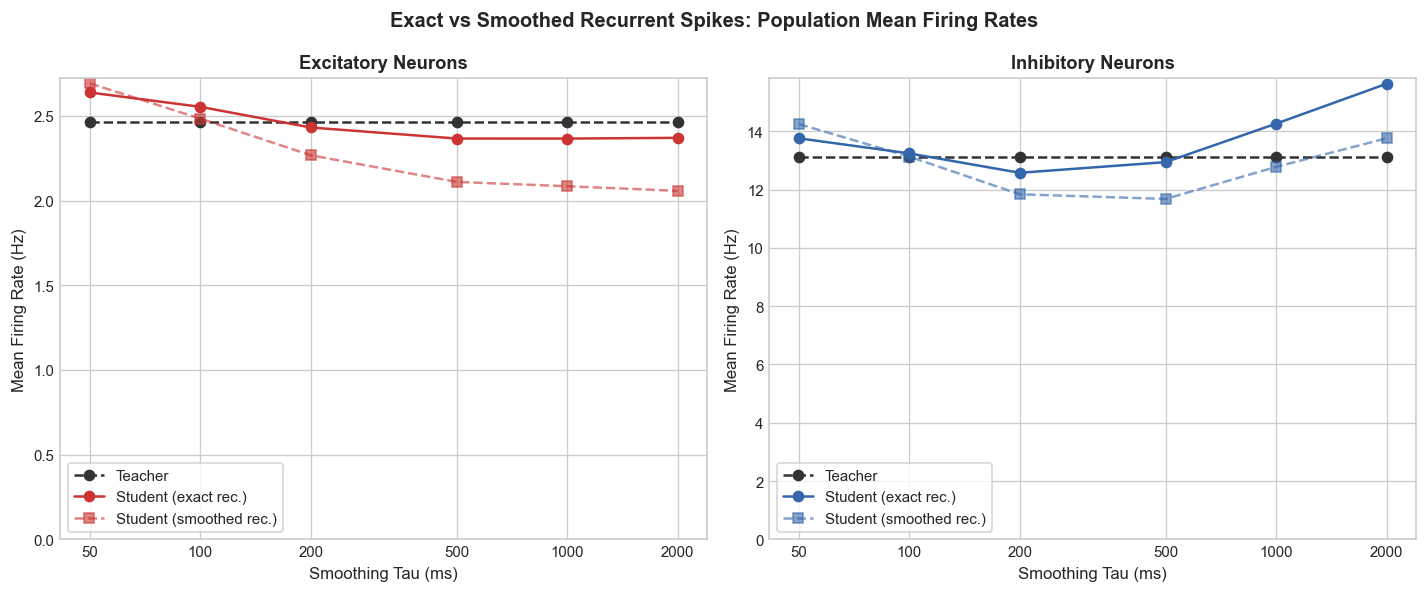

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ct_idx, (ct_label, mask_id, color) in enumerate(
    [("Excitatory", 0, EXCITATORY_COLOR), ("Inhibitory", 1, INHIBITORY_COLOR)]
):
    ax = axes[ct_idx]

    teacher_means = []
    exact_means = []
    smoothed_means = []

    for tau in taus:
        d_exact = exact_data[tau]
        d_smooth = smoothed_data[tau]
        dt = float(d_exact["dt"])
        ct = d_exact["cell_type_indices"]
        mask = ct == mask_id

        dur_exact = d_exact["teacher_spikes"].shape[0] * dt / 1000.0
        dur_smooth = d_smooth["teacher_spikes"].shape[0] * dt / 1000.0

        teacher_means.append(
            d_exact["teacher_spikes"][:, mask].sum(axis=0).mean() / dur_exact
        )
        exact_means.append(
            d_exact["student_spikes"][:, mask].sum(axis=0).mean() / dur_exact
        )
        smoothed_means.append(
            d_smooth["student_spikes"][:, mask].sum(axis=0).mean() / dur_smooth
        )

    ax.plot(
        taus, teacher_means, "o--", color=TEACHER_COLOR, linewidth=1.5, label="Teacher"
    )
    ax.plot(
        taus,
        exact_means,
        "o-",
        color=color,
        linewidth=1.5,
        label="Student (exact rec.)",
    )
    ax.plot(
        taus,
        smoothed_means,
        "s-",
        color=color,
        linewidth=1.5,
        alpha=0.6,
        linestyle="--",
        label="Student (smoothed rec.)",
    )

    ax.set_xscale("log")
    ax.set_xticks(taus)
    ax.set_xticklabels([f"{t:.0f}" for t in taus])
    ax.set_xlabel("Smoothing Tau (ms)")
    ax.set_ylabel("Mean Firing Rate (Hz)")
    ax.set_title(f"{ct_label} Neurons", fontweight="bold")
    ax.set_ylim(0, None)
    ax.legend(frameon=True, fontsize=9)

fig.suptitle(
    "Exact vs Smoothed Recurrent Spikes: Population Mean Firing Rates",
    fontweight="bold",
)
plt.tight_layout()
plt.show()

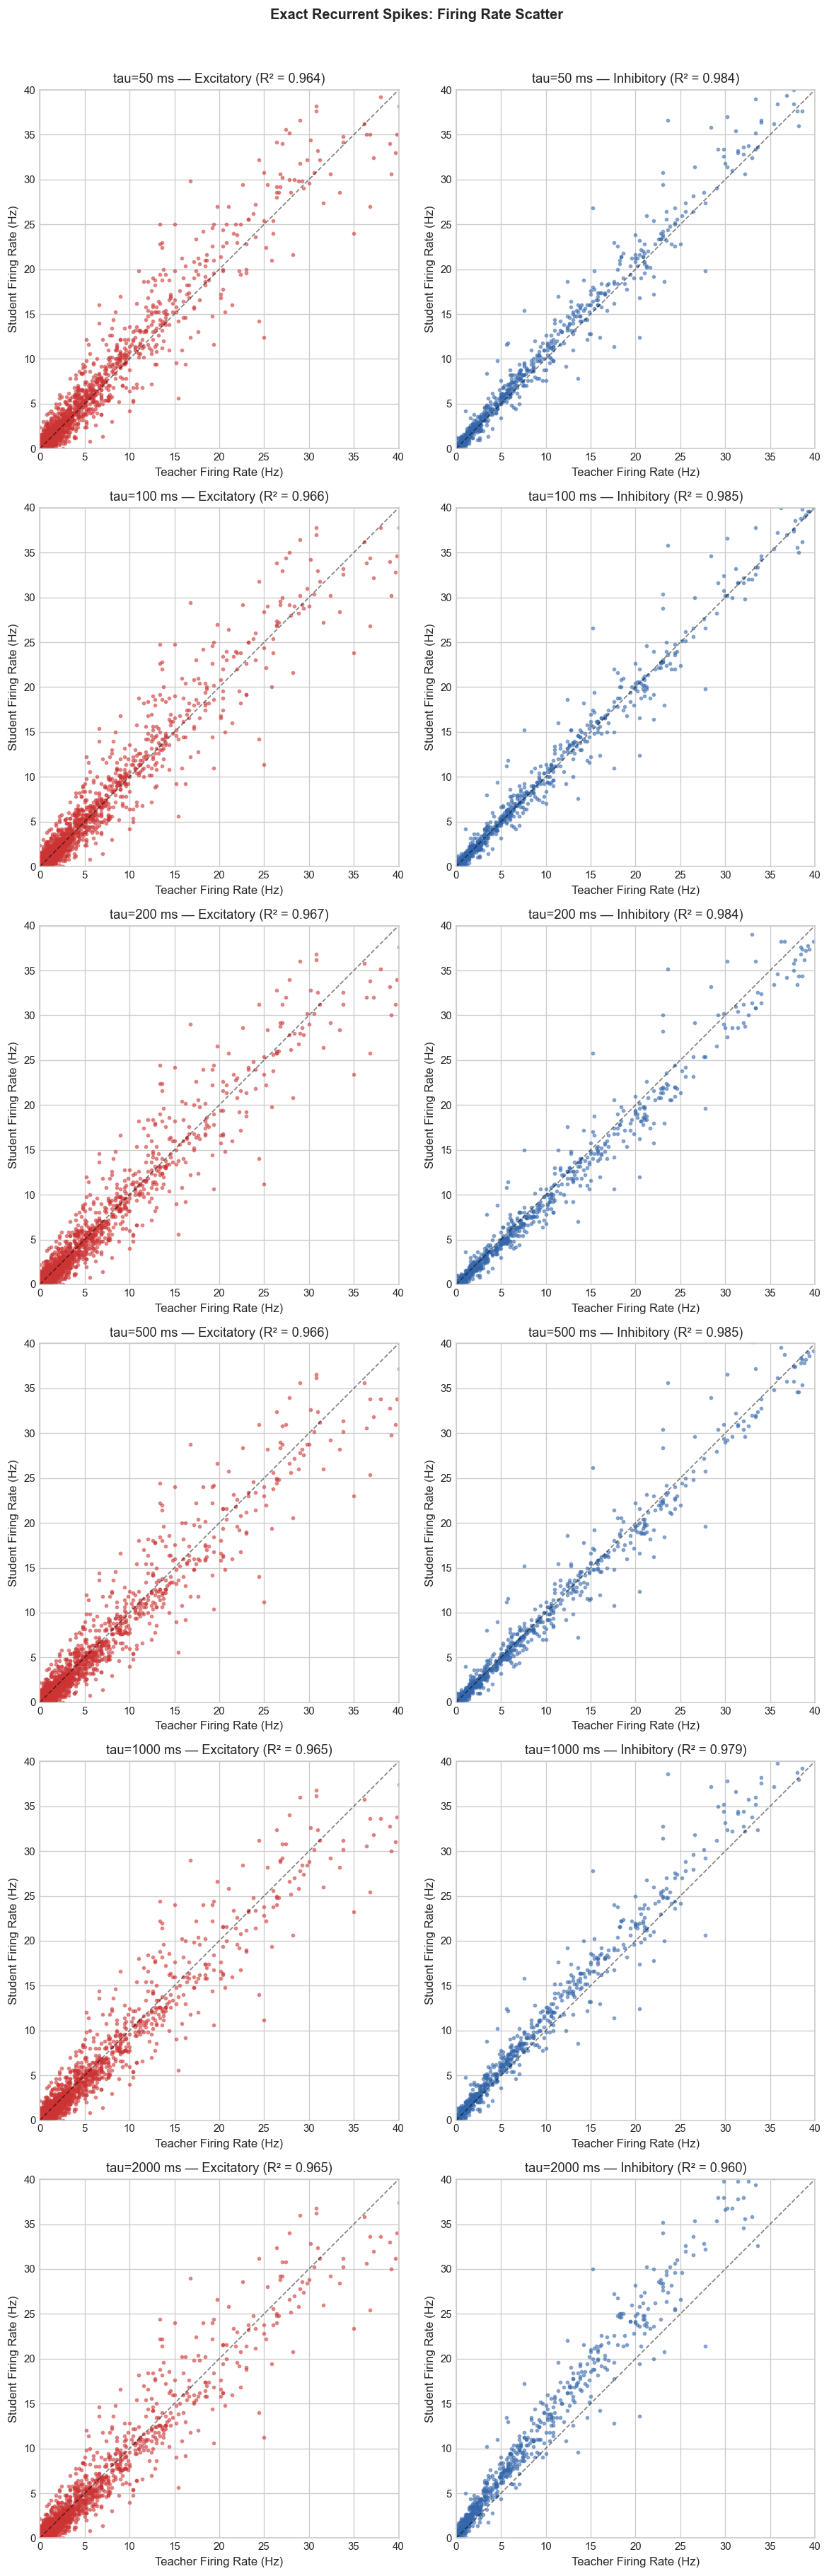

In [14]:
fig, axes = plt.subplots(len(taus), 2, figsize=(10, 5 * len(taus)), squeeze=False)

for row, tau in enumerate(taus):
    d = exact_data[tau]
    dt = float(d["dt"])
    ct = d["cell_type_indices"]

    teacher_fr = firing_rates_from_spikes(d["teacher_spikes"], dt)
    student_fr = firing_rates_from_spikes(d["student_spikes"], dt)

    plot_firing_rate_scatter(
        teacher_fr,
        student_fr,
        ct,
        split_panels=True,
        axes=[axes[row, 0], axes[row, 1]],
        max_rate=MAX_RATE,
        marker_size=6,
        rasterized=True,
    )
    # Prefix titles with tau value
    for col in range(2):
        title = axes[row, col].get_title()
        axes[row, col].set_title(f"tau={tau:.0f} ms \u2014 {title}")

fig.suptitle("Exact Recurrent Spikes: Firing Rate Scatter", fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

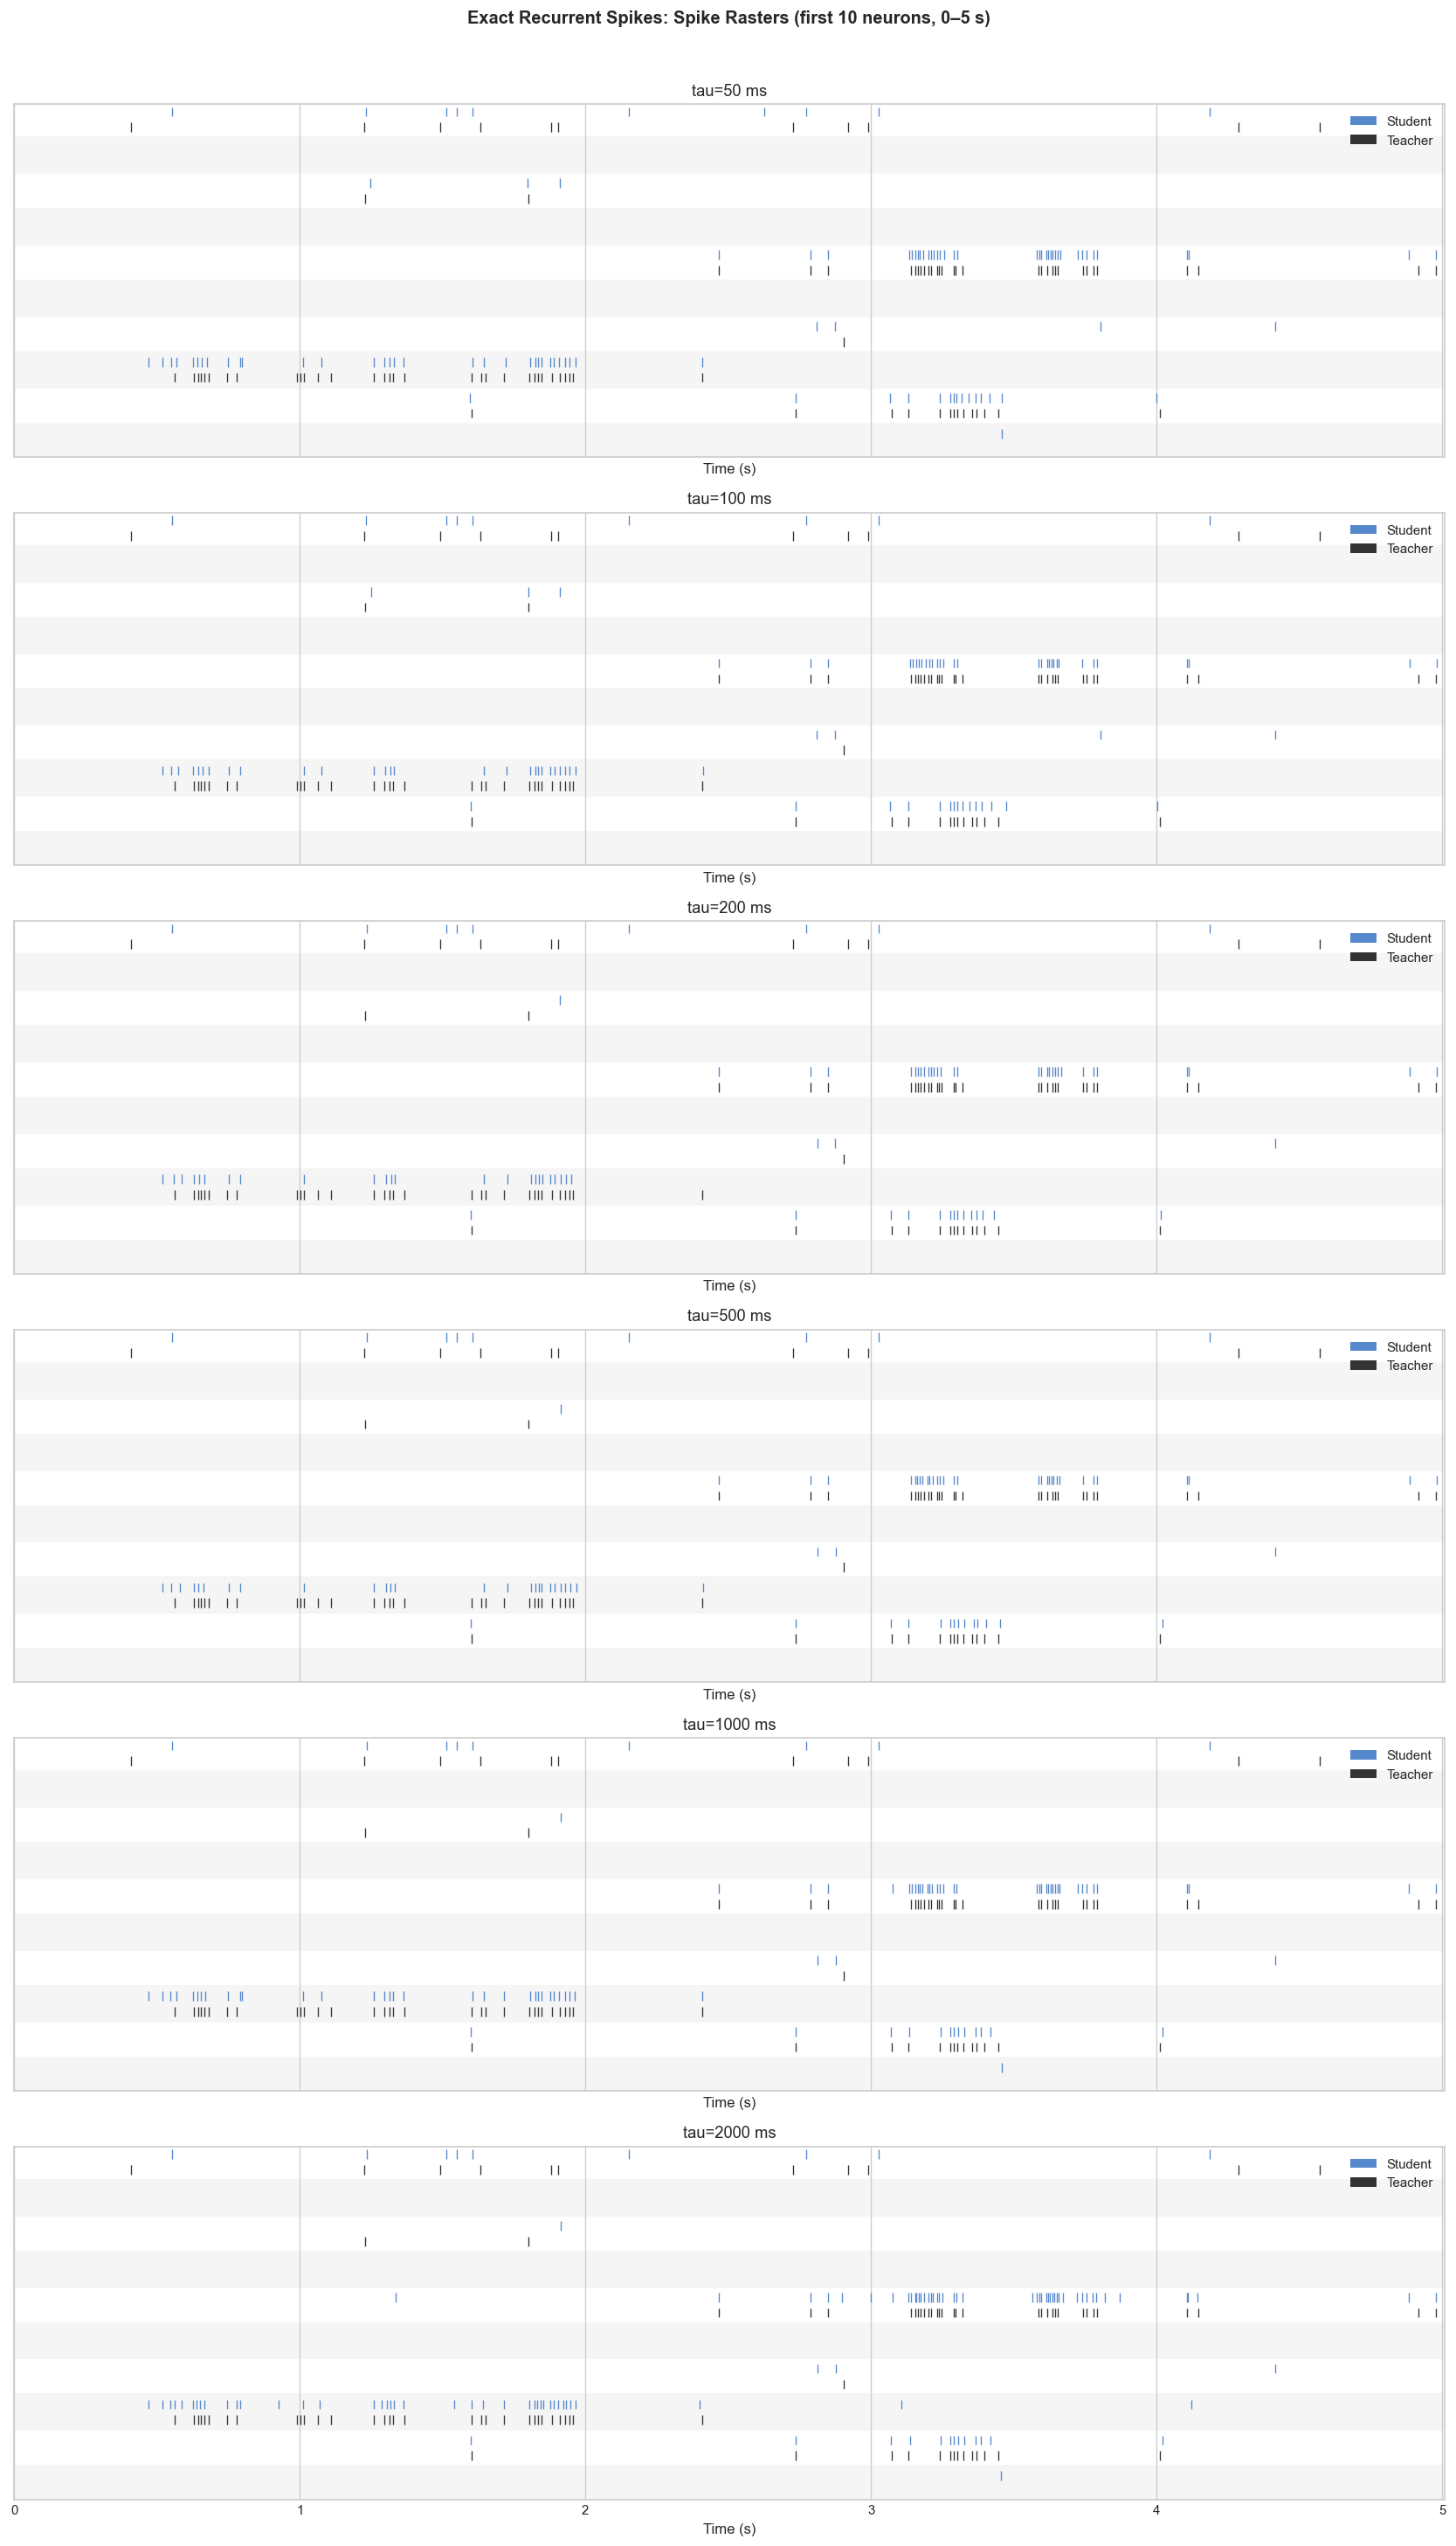

In [15]:
fig, axes = plt.subplots(
    len(taus), 1, figsize=(14, 4 * len(taus)), sharex=True, squeeze=False
)

for row, tau in enumerate(taus):
    d = exact_data[tau]
    dt = float(d["dt"])

    n_5s = int(5000.0 / dt)
    teacher = d["teacher_spikes"][:n_5s, :]
    student = d["student_spikes"][:n_5s, :]

    interleaved, ct_idx = interleave_spike_trains(
        teacher, student, n_neurons=N_NEURONS_RASTER
    )

    plot_spike_trains(
        spikes=interleaved,
        dt=dt,
        cell_type_indices=ct_idx,
        cell_type_names=["Teacher", "Student"],
        cell_type_colors={0: TEACHER_COLOR, 1: STUDENT_COLOR},
        n_neurons_plot=2 * N_NEURONS_RASTER,
        n_compared=2,
        fraction=1.0,
        random_seed=None,
        title=f"tau={tau:.0f} ms",
        ax=axes[row, 0],
    )

axes[-1, 0].set_xlabel("Time (s)")
fig.suptitle(
    "Exact Recurrent Spikes: Spike Rasters (first 10 neurons, 0\u20135 s)",
    fontweight="bold",
    y=1.01,
)
plt.tight_layout()
plt.show()

tau=   50 ms  activity R²=0.9809  fluctuation R²=0.8033
tau=  100 ms  activity R²=0.9824  fluctuation R²=0.8060
tau=  200 ms  activity R²=0.9817  fluctuation R²=0.8073
tau=  500 ms  activity R²=0.9822  fluctuation R²=0.8073
tau= 1000 ms  activity R²=0.9782  fluctuation R²=0.8019
tau= 2000 ms  activity R²=0.9648  fluctuation R²=0.7879


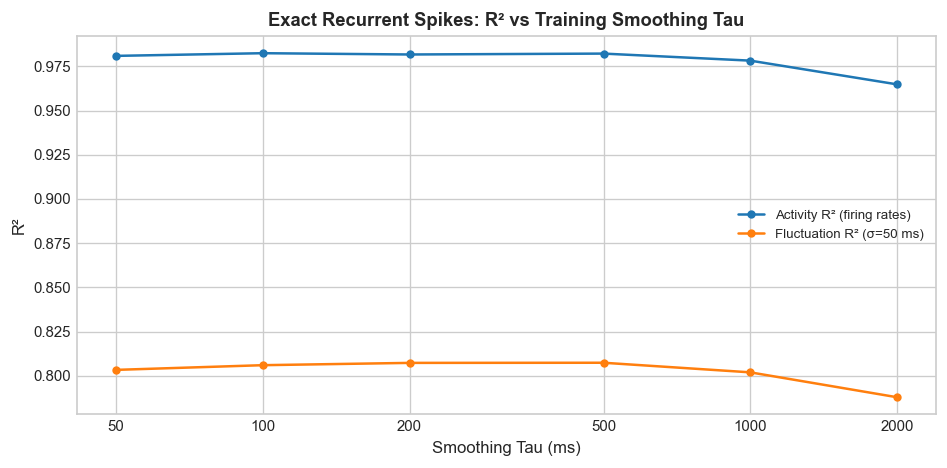

In [16]:
r2_activity_tau = []
r2_fluctuation_tau = []

for tau in taus:
    d = exact_data[tau]
    dt = float(d["dt"])

    teacher_fr = firing_rates_from_spikes(d["teacher_spikes"], dt)
    student_fr = firing_rates_from_spikes(d["student_spikes"], dt)

    r2_act = r_squared(teacher_fr, student_fr)
    r2_activity_tau.append(r2_act)

    r2_flu = fluctuation_r_squared(
        d["teacher_spikes"].astype(np.float32),
        d["student_spikes"].astype(np.float32),
        TAU_MS,
        dt,
    )
    r2_fluctuation_tau.append(r2_flu)

    print(
        f"tau={tau:>5.0f} ms  activity R\u00b2={r2_act:.4f}  fluctuation R\u00b2={r2_flu:.4f}"
    )

fig = plot_r2_vs_parameter(
    taus,
    {
        "Activity R\u00b2 (firing rates)": r2_activity_tau,
        f"Fluctuation R\u00b2 (\u03c3={TAU_MS:.0f} ms)": r2_fluctuation_tau,
    },
    xlabel="Smoothing Tau (ms)",
    title="Exact Recurrent Spikes: R\u00b2 vs Training Smoothing Tau",
)
ax = fig.axes[0]
ax.set_xscale("log")
ax.set_xticks(taus)
ax.set_xticklabels([f"{t:.0f}" for t in taus])
plt.show()

## Summary

In [17]:
rows = []
for tau in taus:
    d = exact_data[tau]
    dt = float(d["dt"])

    teacher_fr = firing_rates_from_spikes(d["teacher_spikes"], dt)
    student_fr = firing_rates_from_spikes(d["student_spikes"], dt)

    r2_act = r_squared(teacher_fr, student_fr)
    r2_flu = fluctuation_r_squared(
        d["teacher_spikes"].astype(np.float32),
        d["student_spikes"].astype(np.float32),
        TAU_MS,
        dt,
    )

    # Scaling factor mean absolute error (final values vs target=1.0)
    df = runs[tau]["df"]
    final = df[df["epoch"] >= 0].iloc[-1]
    sf_vals = np.array(
        [float(final[f"scaling_factors/{key}_value"]) for key, _ in SF_PATHWAYS]
    )
    sf_mae = np.abs(sf_vals - 1.0).mean()

    rows.append(
        {
            "Tau (ms)": f"{tau:.0f}",
            "Activity R²": f"{r2_act:.4f}",
            f"Fluctuation R² (σ={TAU_MS:.0f} ms)": f"{r2_flu:.4f}",
            "SF MAE": f"{sf_mae:.4f}",
        }
    )

summary_df = pd.DataFrame(rows)
summary_df

,Tau (ms),Activity R²,Fluctuation R² (σ=50 ms),SF MAE
0,50,0.9809,0.8033,0.0303
1,100,0.9824,0.8060,0.0253
2,200,0.9817,0.8073,0.0352
3,500,0.9822,0.8073,0.0309
4,1000,0.9782,0.8019,0.0423
5,2000,0.9648,0.7879,0.0706


## Best Model: τ = 100 ms

τ = 100 ms gives the best balance of activity R², fluctuation R², and scaling factor recovery.

Final scaling factors (τ = 100 ms):
  Exc → Exc     1.0083
  Exc → Inh     0.9938
  Inh → Exc     1.0148
  Inh → Inh     0.9784
  FF → Exc      0.9596
  FF → Inh      0.9394


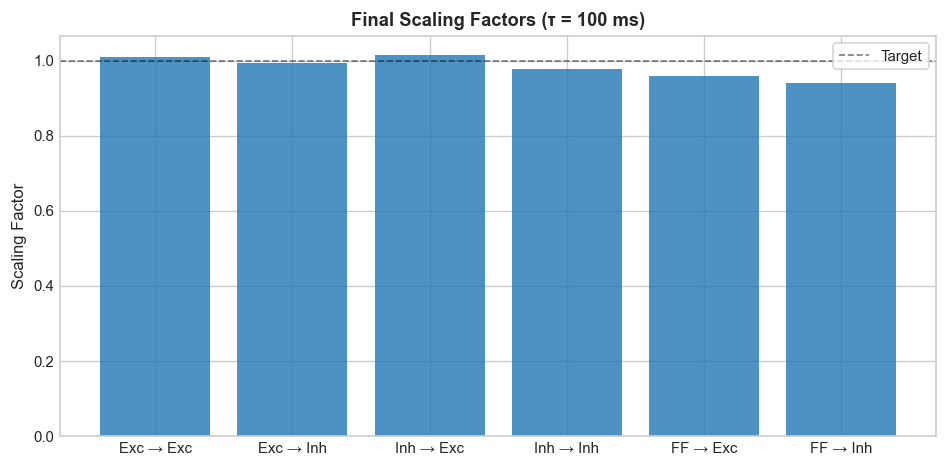

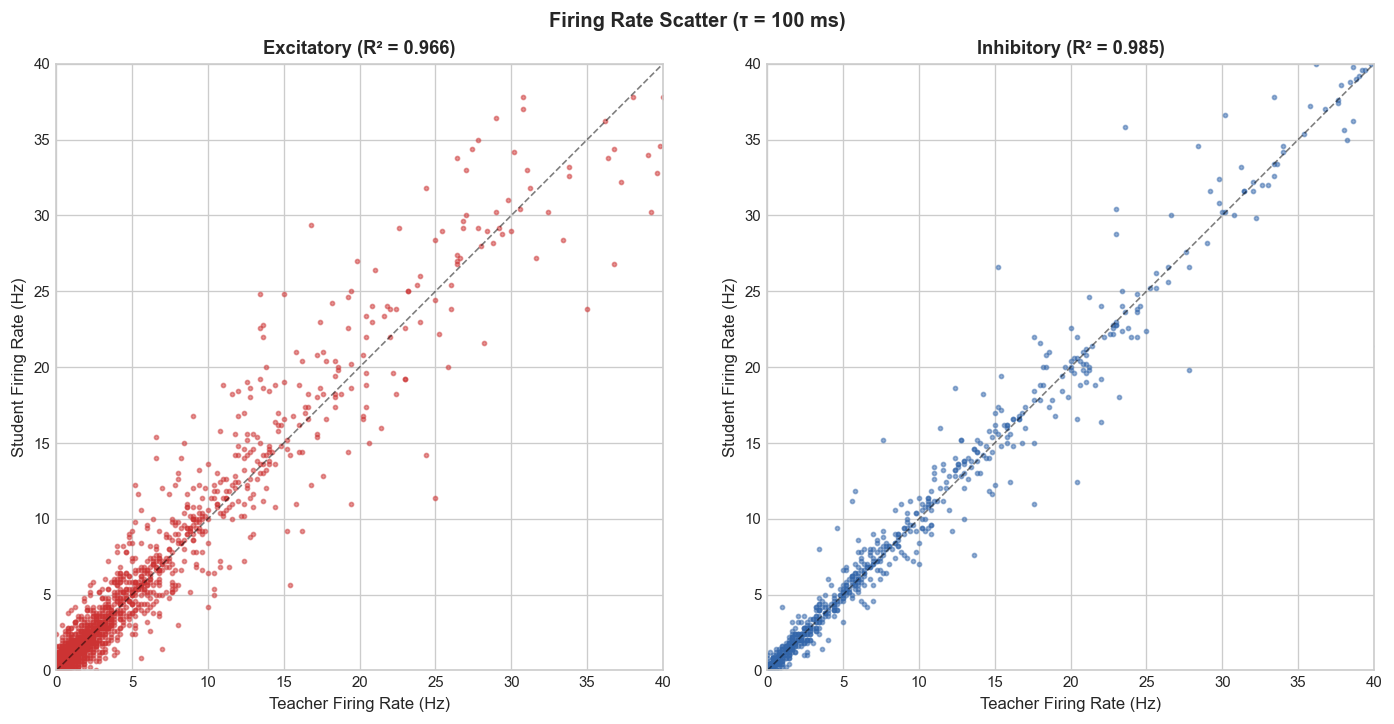

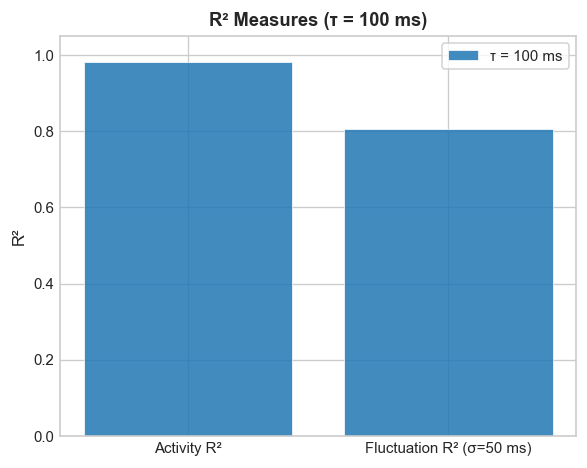


Activity R²:    0.9824
Fluctuation R²: 0.8060


In [18]:
BEST_TAU = 100.0

# ── Scaling factors ──────────────────────────────────────────────────────────
df_best = runs[BEST_TAU]["df"]
final_best = df_best[df_best["epoch"] >= 0].iloc[-1]
sf_best = {
    key: float(final_best[f"scaling_factors/{key}_value"]) for key, _ in SF_PATHWAYS
}

print(f"Final scaling factors (τ = {BEST_TAU:.0f} ms):")
for key, label in SF_PATHWAYS:
    print(f"  {label:<12s}  {sf_best[key]:.4f}")

plot_sf_bar_chart(
    sf_best,
    figsize=(8, 4),
    title=f"Final Scaling Factors (τ = {BEST_TAU:.0f} ms)",
)
plt.show()

# ── Firing rate scatter ──────────────────────────────────────────────────────
d = exact_data[BEST_TAU]
dt = float(d["dt"])
ct = d["cell_type_indices"]
teacher_fr = firing_rates_from_spikes(d["teacher_spikes"], dt)
student_fr = firing_rates_from_spikes(d["student_spikes"], dt)

plot_firing_rate_scatter(
    teacher_fr,
    student_fr,
    ct,
    split_panels=True,
    max_rate=MAX_RATE,
    marker_size=6,
    rasterized=True,
    figsize=(12, 6),
)
plt.suptitle(f"Firing Rate Scatter (τ = {BEST_TAU:.0f} ms)", fontweight="bold")
plt.tight_layout()
plt.show()

# ── R² summary ──────────────────────────────────────────────────────────────
r2_act = r_squared(teacher_fr, student_fr)
r2_flu = fluctuation_r_squared(
    d["teacher_spikes"].astype(np.float32),
    d["student_spikes"].astype(np.float32),
    TAU_MS,
    dt,
)

plot_r2_comparison_bar(
    [f"τ = {BEST_TAU:.0f} ms"],
    {
        "Activity R²": [r2_act],
        f"Fluctuation R² (σ={TAU_MS:.0f} ms)": [r2_flu],
    },
    title=f"R² Measures (τ = {BEST_TAU:.0f} ms)",
    figsize=(5, 4),
)
plt.show()

print(f"\nActivity R²:    {r2_act:.4f}")
print(f"Fluctuation R²: {r2_flu:.4f}")